In [15]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

4 qubit Cluster State preparation circuit 

In [16]:
# ==========================================================
# Dense Coding using 4 qubit Cluster State
# ==========================================================
qc = QuantumCircuit(4,4)

# ----------------------------------------------------------
# Cluster State Preparation
# ----------------------------------------------------------

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.barrier()
qc.cz(0,1)
qc.cz(1,2)
qc.cz(2,3)
qc.barrier()
qc.h(0)
qc.h(3)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

Alice's Encoding operation 

In [ ]:
#----------------------------------------------------------
# Alice Encoding
# ----------------------------------------------------------
message = "1100"  

if message == "0000":
    pass

elif message == "1010":
    qc.x(1)

elif message == "1110":
    qc.y(1)

elif message == "0100":
    qc.z(1)

elif message == "1000":
    qc.x(0)

elif message == "0010":
    qc.x(0)
    qc.x(1)

elif message == "0110":
    qc.x(0)
    qc.y(1)

elif message == "1100":
    qc.x(0)
    qc.z(1)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(4, "q"), index=0>, <Qubit register=(4, "q"), index=1>, <Qubit register=(4, "q"), index=2>, <Qubit register=(4, "q"), index=3>), clbits=())

All qubits which were in possession of Alice are now send to Bob

Bob's Decoding Operation

In [18]:
# ----------------------------------------------------------
# Bob Decoding
# ----------------------------------------------------------

qc.h(0)
qc.h(3)
qc.barrier()

qc.cz(2,3)
qc.cz(1,2)
qc.cz(0,1)
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)
qc.h(3)
qc.barrier()

qc.measure([0,1,2,3],[0,1,2,3])

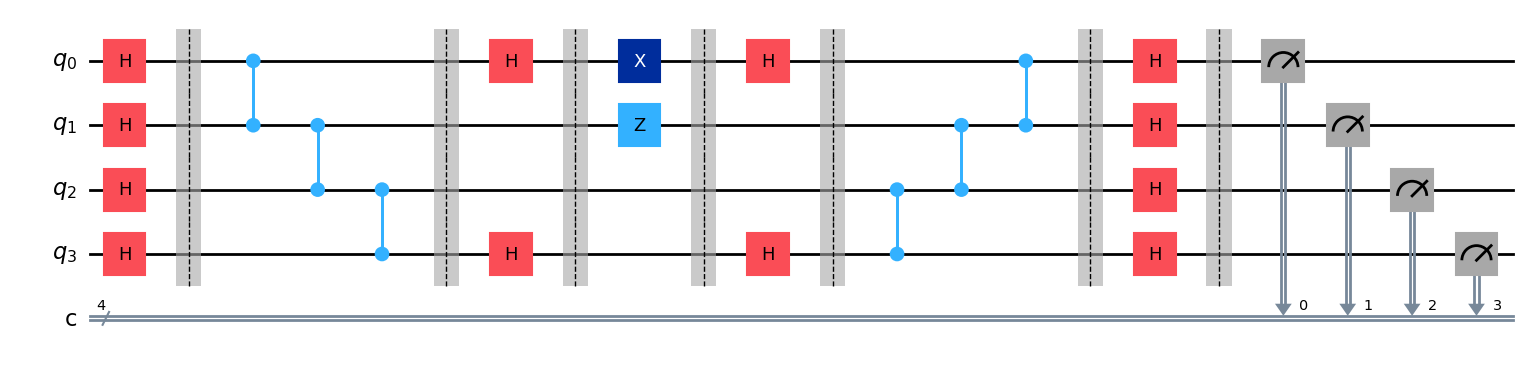

In [19]:
qc.draw(output="mpl")

In [20]:
print(qc.depth())

12


{'0000': 0, '0001': 0, '0010': 0, '0011': 4096, '0100': 0, '0101': 0, '0110': 0, '0111': 0, '1000': 0, '1001': 0, '1010': 0, '1011': 0, '1100': 0, '1101': 0, '1110': 0, '1111': 0}


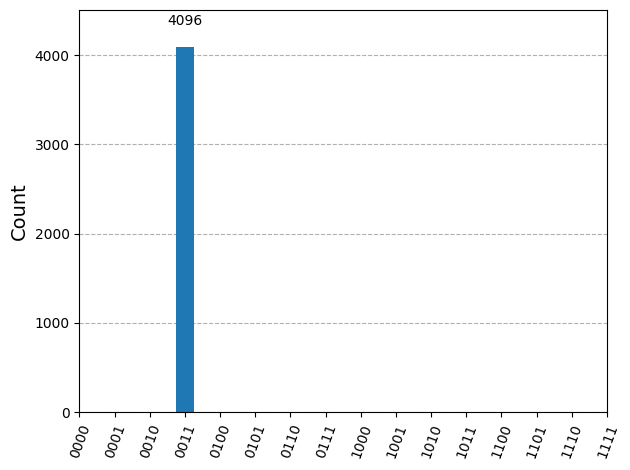

In [21]:
simulator = Aer.get_backend('qasm_simulator')

result = simulator.run(qc, shots=4096).result()
counts = result.get_counts()

# Add missing states with zero counts
all_states = ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']

counts_complete = {state: counts.get(state, 0) for state in all_states}

print(counts_complete)

plot_histogram(counts_complete)

In [ ]:
import numpy as np
from itertools import product
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# -----------------------------
# Preparation of cluster state
# -----------------------------

def cluster_state():
    qc = QuantumCircuit(4)

    qc.h([0,1,2,3])
    qc.cz(0,1)
    qc.cz(1,2)
    qc.cz(2,3)
    qc.h(0)
    qc.h(3)

    return qc

base = cluster_state()

paulis = ['I','X','Y','Z']

states = []
labels = []

for p0,p1 in product(paulis, repeat=2):

    qc = base.copy()

    if p0!='I':
        getattr(qc,p0.lower())(0)

    if p1!='I':
        getattr(qc,p1.lower())(1)

    psi = Statevector.from_instruction(qc).data

    states.append(psi)
    labels.append(p0+p1)

In [23]:
N = len(states)

G = np.zeros((N,N),dtype=complex)

for i in range(N):
    for j in range(N):
        G[i,j] = np.vdot(states[i],states[j])

print(np.round(np.abs(G),6))

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [24]:
print("\nNon-orthogonal pairs\n")

for i in range(N):
    for j in range(i+1,N):

        if abs(G[i,j]) > 1e-10:

            print(labels[i], labels[j], G[i,j])


Non-orthogonal pairs

II ZZ (0.9999999999999991+0j)
IX ZY 0.9999999999999991j
IY ZX -0.9999999999999991j
IZ ZI (0.9999999999999991+0j)
XI YZ 0.9999999999999991j
XX YY (-0.9999999999999991+0j)
XY YX (0.9999999999999991+0j)
XZ YI 0.9999999999999991j
